In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

In [2]:
df = pd.read_csv("../dataset/toyona_gold_cleaned_mulp_prod.csv")
df.head()

,возраст,пол,семейное положение,количество иждивенцев,профессия,статус клиента,зарплата,сумма кредита,ежемесячное погашение по графику,активные кредиты,первоначальный взнос,наличие карты,филиал,название продукта,is_bad_client
0,49.0,female,замужем,2.000000,nonvoy,активный,2000000.0,15232757,1269396,2,0,нет,navoiy,кулон,0
1,37.0,female,замужем,1.000000,tozalik xodimi,активный,3500000.0,4496189,374682,2,0,нет,turkiston,кулон,0
2,33.0,female,замужем,2.000000,bolalar hamshirasi,активный,1500000.0,3566595,297216,1,0,нет,navoiy,кулон,0
3,51.0,male,женат,2.449843,taksist,активный,4000000.0,7544792,628732,2,0,нет,turkiston,кулон; кулон,0
4,46.0,male,женат,1.000000,katta usta,активный,4000000.0,4608685,384057,1,0,нет,navoiy,кулон,0


In [3]:
df['is_bad_client'].value_counts()

0    631
1     71
Name: is_bad_client, dtype: int64

In [4]:
npl_ratio = df["is_bad_client"].mean() * 100
print(f"NPL: {npl_ratio:.2f}%")

NPL: 10.11%


In [6]:
class MultiValueSplitter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        def split_value(x):
            if isinstance(x, str):
                return x.split(';')
            elif pd.isna(x):
                return ['missing']
            else:
                return x  # In case input is already a list
        # Return a list of lists, no reshaping
        return [split_value(x) for x in X.ravel()]

In [7]:
class SafeMultiLabelBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self

    def transform(self, X):
        cleaned = [[label for label in row if label in self.mlb.classes_] for row in X]
        X_trans = self.mlb.transform(cleaned)
        return pd.DataFrame(X_trans, columns=self.mlb.classes_)

In [8]:
import pickle
with open("../model/tuyona_gold_rf_model_v2.pkl", "rb") as f:
    model = pickle.load(f)

In [9]:
col_map = {
    'возраст': 'age',
    'пол': 'gender',
    'семейное положение': 'marital_status',
    'количество иждивенцев': 'dependents',
    'профессия': 'occupation',
    'статус клиента': 'customer_status',
    'зарплата': 'salary',
    'сумма кредита': 'loan_amount',
    'ежемесячное погашение по графику': 'monthly_payment',
    'активные кредиты': 'active_loans',
    'первоначальный взнос': 'down_payment',
    'наличие карты': 'has_card',
    'филиал': 'branch',
    'название продукта': 'product_name'
}

In [10]:
df = df.rename(columns=col_map)

In [11]:
df.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name,is_bad_client
0,49.0,female,замужем,2.000000,nonvoy,активный,2000000.0,15232757,1269396,2,0,нет,navoiy,кулон,0
1,37.0,female,замужем,1.000000,tozalik xodimi,активный,3500000.0,4496189,374682,2,0,нет,turkiston,кулон,0
2,33.0,female,замужем,2.000000,bolalar hamshirasi,активный,1500000.0,3566595,297216,1,0,нет,navoiy,кулон,0
3,51.0,male,женат,2.449843,taksist,активный,4000000.0,7544792,628732,2,0,нет,turkiston,кулон; кулон,0
4,46.0,male,женат,1.000000,katta usta,активный,4000000.0,4608685,384057,1,0,нет,navoiy,кулон,0


In [12]:
marital_status_mapping = {
    'женат': 'married',
    'не замужем': 'single',
    'замужем': 'married',
    'холост': 'single'
}
df['marital_status'] = df['marital_status'].replace(marital_status_mapping)

In [13]:
customer_status_mapping = {
    'активный': 'active',
}
df['customer_status'] = df['customer_status'].replace(customer_status_mapping)

In [14]:
has_card_mapping = {
    'да': 'yes',
    'нет': 'no'
}
df['has_card'] = df['has_card'].replace(has_card_mapping)

In [15]:
def replace_product_name(name: str):
    if not isinstance(name, str) or name.strip() == "":
        return "ring"

    parts = [part.strip() for part in name.split(";") if part.strip()]

    def map_single(n: str):
        first = n[0:3].lower()
        if first in ["кул"]:
            return "pendant"
        elif first in ["ком"]:
            return "set"
        elif first in ["кол"]:
            return "ring"
        elif first in ["цеп"]:
            return "chain"
        elif first in ["сер"]:
            return "earrings"
        else:
            return "pendant"
        
    return "; ".join(map(map_single, parts))


In [16]:
df["product_name"] = df["product_name"].apply(replace_product_name)
df.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name,is_bad_client
0,49.0,female,married,2.000000,nonvoy,active,2000000.0,15232757,1269396,2,0,no,navoiy,pendant,0
1,37.0,female,married,1.000000,tozalik xodimi,active,3500000.0,4496189,374682,2,0,no,turkiston,pendant,0
2,33.0,female,married,2.000000,bolalar hamshirasi,active,1500000.0,3566595,297216,1,0,no,navoiy,pendant,0
3,51.0,male,married,2.449843,taksist,active,4000000.0,7544792,628732,2,0,no,turkiston,pendant; pendant,0
4,46.0,male,married,1.000000,katta usta,active,4000000.0,4608685,384057,1,0,no,navoiy,pendant,0


In [17]:
def deduplicate_cell(value: str) -> str:
    if not isinstance(value, str) or value.strip() == "":
        return value

    seen = set()
    unique_parts = []
    for part in [p.strip() for p in value.split(";") if p.strip()]:
        if part not in seen:
            seen.add(part)
            unique_parts.append(part)
    return "; ".join(unique_parts)


In [18]:
df["product_name"] = df["product_name"].apply(deduplicate_cell)
df['product_name'].value_counts()

pendant               439
set                   176
ring                   32
set; pendant           12
ring; pendant          12
pendant; set           11
chain                   7
pendant; ring           6
chain; pendant          3
earrings                2
pendant; chain          1
set; pendant; ring      1
Name: product_name, dtype: int64

In [19]:
X = df.drop(columns=["is_bad_client"])
y = df["is_bad_client"]

In [20]:
X.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name
0,49.0,female,married,2.000000,nonvoy,active,2000000.0,15232757,1269396,2,0,no,navoiy,pendant
1,37.0,female,married,1.000000,tozalik xodimi,active,3500000.0,4496189,374682,2,0,no,turkiston,pendant
2,33.0,female,married,2.000000,bolalar hamshirasi,active,1500000.0,3566595,297216,1,0,no,navoiy,pendant
3,51.0,male,married,2.449843,taksist,active,4000000.0,7544792,628732,2,0,no,turkiston,pendant
4,46.0,male,married,1.000000,katta usta,active,4000000.0,4608685,384057,1,0,no,navoiy,pendant


In [21]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_bad_client, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [23]:
len(X_train), len(X_test), len(y_train), len(y_test)

(491, 211, 491, 211)

In [24]:
y_pred = model.predict(X_test)  
y_proba = model.predict_proba(X_test)[:, 1]

/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_G

In [25]:
y_test.value_counts()

0    190
1     21
Name: is_bad_client, dtype: int64

In [26]:
npl_ratio = y_test.mean() * 100
print(f"NPL: {npl_ratio:.2f}%")

NPL: 9.95%


In [27]:
print("Classification Report (по 0/1):")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Classification Report (по 0/1):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       190
           1       0.83      0.90      0.86        21

    accuracy                           0.97       211
   macro avg       0.91      0.94      0.92       211
weighted avg       0.97      0.97      0.97       211

Confusion Matrix:
[[186   4]
 [  2  19]]
ROC-AUC: 0.9779448621553885


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix


thresholds = np.linspace(0, 1, 101)
f1_scores, precisions, recalls, npls, accuracies = [], [], [], [], []
tps, tns, fps, fns = [], [], [], []

thrs = []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    
    
    tp, fp, fn, tn = confusion_matrix(y_test, y_pred_thr).ravel()

    tps.append(tp)
    tns.append(tn)
    fps.append(fp)
    fns.append(fn)

    npl = fn / (fn + tp) if (tp + fn) > 0 else 0
    npls.append(round(npl*100, 2))

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    precisions.append(round(prec *100,2))

    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    recalls.append(round(rec *100, 2))

    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    f1_scores.append(round(f1 *100 ,2))

    acc = (tp + tn) / (tp + tn + fp + fn)
    accuracies.append(round(acc *100 ,2))

    thrs.append(round(thr * 100, 2))

results = pd.DataFrame({
    "threshold": thrs,
    "precision": precisions,
    "recall": recalls,
    "f1": f1_scores,
    "accuracy": accuracies,
    "npl": npls,
    "tp": tps,
    "tn": tns,
    "fp": fps,
    "fn": fns
})

results.to_csv("tuyona_gold_mult_prod_metrics_thresholds.csv", index=False)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Лучший порог: {best_threshold:.2f}")
print(f"F1-score: {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall: {recalls[best_idx]:.4f}")
print(f"NPL: {npls[best_idx]:.4f}")
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Лучший порог: 0.65
F1-score: 98.9600
Precision: 100.0000
Recall: 97.9400
NPL: 2.0600
ROC-AUC: 0.9779448621553885


In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, confusion_matrix

def find_best_threshold_balanced(model, X_valid, y_valid, beta=1.0, grid_size=101, f1_tol=0.01,
                                 min_precision=None, min_recall=None):
    
    y_proba = model.predict_proba(X_valid)[:, 1]
    thresholds = np.linspace(0.0, 1.0, grid_size)

    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
        
    
        prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
        f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
        fbet = fbeta_score(y_valid, y_pred, beta=beta, zero_division=0) * 100
        npl = (fn / (tp + fn)) * 100 if (tp + fn) > 0 else np.nan
        acc = (tp + tn) / (tp + tn + fp + fn) * 100

        rows.append((int(round(t * 100)), round(prec, 2), round(rec, 2), round(f1, 2), round(fbet, 2), round(acc, 2), round(abs(prec - rec), 2), npl))

    metrics_df = pd.DataFrame(
        rows,
        columns=["threshold", "precision", "recall", "f1", "f_beta", "accuracy", "prec_recall_gap", "npl"]
    )

    cand = metrics_df.copy()

    if min_precision is not None:
        cand = cand[cand["precision"] >= min_precision]
    if min_recall is not None:
        cand = cand[cand["recall"] >= min_recall]
    

    if cand.empty:
        cand = metrics_df

    score_col = "f1" if beta == 1.0 else "f_beta"
    max_score = cand[score_col].max()
    
   
    near_opt = cand[cand[score_col] >= max_score * (1 - f1_tol)]
   
 
    best_row = near_opt.sort_values(
        ["prec_recall_gap", score_col, "threshold"],
        ascending=[True, False, True]
    ).iloc[0]
    
    best_threshold = float(best_row["threshold"])
    

    return best_threshold, metrics_df, best_row

In [32]:
best_thr, metrics_table, best_metrics = find_best_threshold_balanced(
    model, X_test, y_test,
    beta=1.0,
    grid_size=101,
    f1_tol=0.01
)

print(f"Лучший порог: {best_thr:.3f}")
print("Метрики на лучшем пороге:")
print(best_metrics)

/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Лучший порог: 56.000
Метрики на лучшем пороге:
threshold          56.000000
precision          94.740000
recall             85.710000
f1                 90.000000
f_beta             90.000000
accuracy           98.100000
prec_recall_gap     9.020000
npl                14.285714
Name: 56, dtype: float64


In [33]:
best_thr

56.0

In [34]:
best_thr = best_thr / 100 

In [35]:
metrics_df_copy = metrics_table.copy()

In [36]:
df_metrics = metrics_df_copy[['threshold', 'precision', 'recall', 'f1', 'accuracy', 'npl']]

In [37]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_opt = (y_proba >= best_thr).astype(int)

print("\nClassification report @ optimal threshold:", best_thr *100)
print(classification_report(y_test, y_pred_opt, digits=2))
print("Confusion matrix @ optimal threshold:", best_thr *100)
print(confusion_matrix(y_test, y_pred_opt))

print("\nTop 10 порогов по F1 + баланс precision/recall + NPL:")
print(
    df_metrics.sort_values(["f1"], ascending=[False,])
                 .head(10)
                 .round(3)
)



Classification report @ optimal threshold: 56.00000000000001
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       190
           1       0.95      0.86      0.90        21

    accuracy                           0.98       211
   macro avg       0.97      0.93      0.94       211
weighted avg       0.98      0.98      0.98       211

Confusion matrix @ optimal threshold: 56.00000000000001
[[189   1]
 [  3  18]]

Top 10 порогов по F1 + баланс precision/recall + NPL:
    threshold  precision  recall     f1  accuracy     npl
60         60      94.74   85.71  90.00      98.1  14.286
56         56      94.74   85.71  90.00      98.1  14.286
58         58      94.74   85.71  90.00      98.1  14.286
59         59      94.74   85.71  90.00      98.1  14.286
61         61      94.74   85.71  90.00      98.1  14.286
62         62      94.74   85.71  90.00      98.1  14.286
63         63      94.74   85.71  90.00      98.1  14.286
64         64

/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [73]:
df_metrics.to_csv("toyona_gold_metrics_table.csv", index=False)

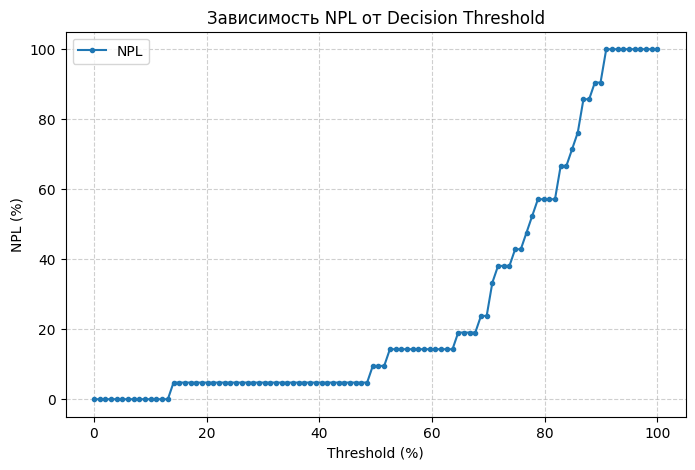

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def npl_at_thresholds(y_true, y_proba, thresholds):
    npl_scores = []
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        #NPL = FN / (TP + FN)
        if (tp + fn) > 0:
            npl = fn / (tp + fn)
        else:
            npl = np.nan
        npl_scores.append(npl)
    return npl_scores


thresholds = np.linspace(0, 1, 100)
npl_values = npl_at_thresholds(y_test, y_proba, thresholds)


plt.figure(figsize=(8,5))
plt.plot(thresholds * 100, np.array(npl_values) * 100, marker="o", markersize=3, label="NPL")
plt.xlabel("Threshold (%)")
plt.ylabel("NPL (%)")
plt.title("Зависимость NPL от Decision Threshold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

